In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("../data/processed/feature_engineered_gpu_dataset.csv")

In [3]:
print("Shape:", df.shape)

df.head()

Shape: (1165, 27)


,manufacturer,gpu_name,releaseyear,memsize,gpuclock,memclock,unifiedshader,tmu,rop,igp,bus,memtype,gpuchip,g3dmark,g2dmark,price,gpuvalue,tdp,powerperformance,testdate,category,opencl,performance_per_watt,performance_per_gb,performance_per_shader,gpu_age,performance_category
0,AMD,RADEON RX 6500 XT,2022.0,4.0,1560,1313.0,10752.0,336,112,No,PCIe 4.0 x16,GDDR6X,GA102,9445,910,199.99,47.23,NaN,NaN,2022,Unknown,52512.0,NaN,2361.250,0.878441,4.0,Extreme
1,AMD,RADEON RX 6400,2022.0,4.0,1395,1219.0,10496.0,328,112,No,PCIe 4.0 x16,GDDR6X,GA102,6958,899,159.99,43.49,NaN,NaN,2022,Unknown,NaN,NaN,1739.500,0.662919,4.0,Extreme
2,AMD,RADEON PRO W6400,2022.0,4.0,1080,2000.0,10240.0,320,96,No,PCIe 4.0 x16,GDDR6,GA102,5916,621,NaN,NaN,NaN,NaN,2022,Unknown,NaN,NaN,1479.000,0.577734,4.0,Extreme
3,NVIDIA,GEFORCE RTX 3090 TI,2022.0,24.0,1980,1313.0,7168.0,224,80,No,PCIe 4.0 x16,GDDR6X,AD104,29094,1117,2099.99,13.85,450.0,64.65,2022,Unknown,229738.0,64.653333,1212.250,4.058873,4.0,Extreme
4,AMD,RADEON RX 6700S,2022.0,8.0,1440,945.0,4096.0,256,64,No,PCIe 3.0 x16,HBM2,Vega 10,11989,829,NaN,NaN,NaN,NaN,2022,Unknown,72317.0,NaN,1498.625,2.927002,4.0,Extreme


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1165 entries, 0 to 1164
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   manufacturer            1165 non-null   str    
 1   gpu_name                1165 non-null   str    
 2   releaseyear             1165 non-null   float64
 3   memsize                 1165 non-null   float64
 4   gpuclock                1165 non-null   int64  
 5   memclock                1165 non-null   float64
 6   unifiedshader           1165 non-null   float64
 7   tmu                     1165 non-null   int64  
 8   rop                     1165 non-null   int64  
 9   igp                     1165 non-null   str    
 10  bus                     1165 non-null   str    
 11  memtype                 1165 non-null   str    
 12  gpuchip                 1165 non-null   str    
 13  g3dmark                 1165 non-null   int64  
 14  g2dmark                 1165 non-null   int64  
 15

In [6]:
df.describe()

,releaseyear,memsize,gpuclock,memclock,unifiedshader,tmu,rop,g3dmark,g2dmark,price,gpuvalue,tdp,powerperformance,testdate,opencl,performance_per_watt,performance_per_gb,performance_per_shader,gpu_age
count,1165.000000,1165.000000,1165.000000,1165.000000,1165.000000,1165.000000,1165.000000,1165.00000,1165.000000,473.000000,473.000000,596.000000,596.000000,1165.000000,518.000000,596.000000,1165.000000,1165.000000,1165.000000
mean,2010.936481,2.380055,712.137339,972.031760,669.218884,41.214592,17.294421,2401.64721,339.115021,447.922135,10.961353,96.035570,29.103285,2012.893562,22374.196911,29.103357,787.980043,6.322718,15.063519
std,4.899970,4.168435,359.725781,432.511065,880.129706,47.697738,17.369247,4385.20177,240.013335,803.492588,11.337064,84.493523,28.129249,3.610647,34702.048947,28.129484,646.031288,12.607292,4.899970
min,1999.000000,0.032000,10.000000,10.000000,8.000000,0.000000,0.000000,1.00000,20.000000,17.500000,0.000000,7.000000,0.630000,2009.000000,220.000000,0.618182,2.929688,0.002604,4.000000
25%,2007.000000,0.512000,475.000000,790.000000,240.000000,8.000000,4.000000,128.00000,153.000000,114.000000,1.830000,33.000000,7.640000,2009.000000,3560.000000,7.642143,325.750000,0.385417,12.000000
50%,2011.000000,1.024000,650.000000,900.000000,384.000000,24.000000,9.000000,628.00000,271.000000,199.990000,7.000000,65.000000,19.155000,2012.000000,8096.500000,19.155714,590.000000,1.911458,15.000000
75%,2014.000000,2.000000,900.000000,1250.000000,768.000000,56.000000,24.000000,2310.00000,469.000000,415.000000,16.970000,142.750000,38.285000,2015.000000,23696.500000,38.283333,1025.500000,5.023438,19.000000
max,2022.000000,48.000000,2321.000000,2250.000000,10752.000000,336.000000,112.000000,29094.00000,1117.000000,8999.000000,69.730000,500.000000,204.000000,2022.000000,229738.000000,204.000000,4151.367188,158.562500,27.000000


In [7]:
missing = df.isnull().sum()

missing[missing > 0]

price                   692
gpuvalue                692
tdp                     569
powerperformance        569
opencl                  647
performance_per_watt    569
dtype: int64

In [8]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent[missing_percent > 0]

price                   59.399142
gpuvalue                59.399142
tdp                     48.841202
powerperformance        48.841202
opencl                  55.536481
performance_per_watt    48.841202
dtype: float64

In [9]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [10]:
df['g3dmark'].describe()

count     1165.00000
mean      2401.64721
std       4385.20177
min          1.00000
25%        128.00000
50%        628.00000
75%       2310.00000
max      29094.00000
Name: g3dmark, dtype: float64

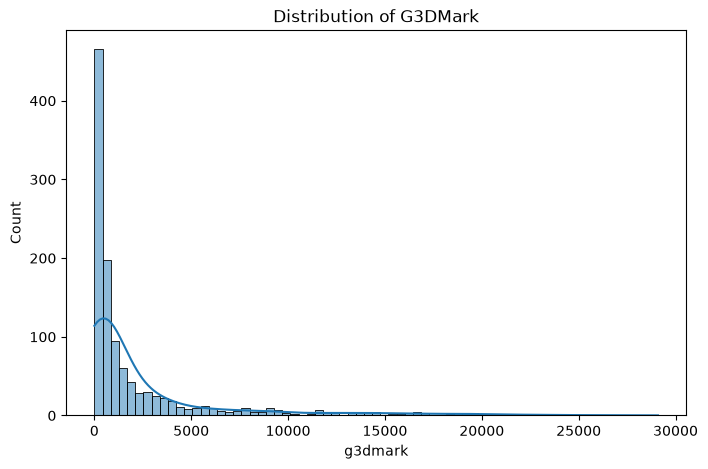

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df['g3dmark'], kde=True)
plt.title("Distribution of G3DMark")
plt.show()

In [12]:
df['performance_category'].value_counts()

performance_category
Low        298
High       293
Extreme    289
Mid        285
Name: count, dtype: int64

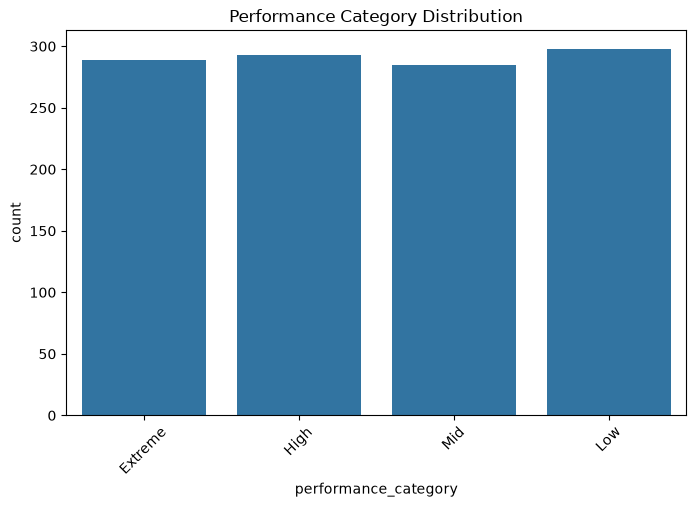

In [13]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='performance_category')
plt.xticks(rotation=45)
plt.title("Performance Category Distribution")
plt.show()

In [14]:
df.dtypes

manufacturer                  str
gpu_name                      str
releaseyear               float64
memsize                   float64
gpuclock                    int64
memclock                  float64
unifiedshader             float64
tmu                         int64
rop                         int64
igp                           str
bus                           str
memtype                       str
gpuchip                       str
g3dmark                     int64
g2dmark                     int64
price                     float64
gpuvalue                  float64
tdp                       float64
powerperformance          float64
testdate                    int64
category                      str
opencl                    float64
performance_per_watt      float64
performance_per_gb        float64
performance_per_shader    float64
gpu_age                   float64
performance_category          str
dtype: object

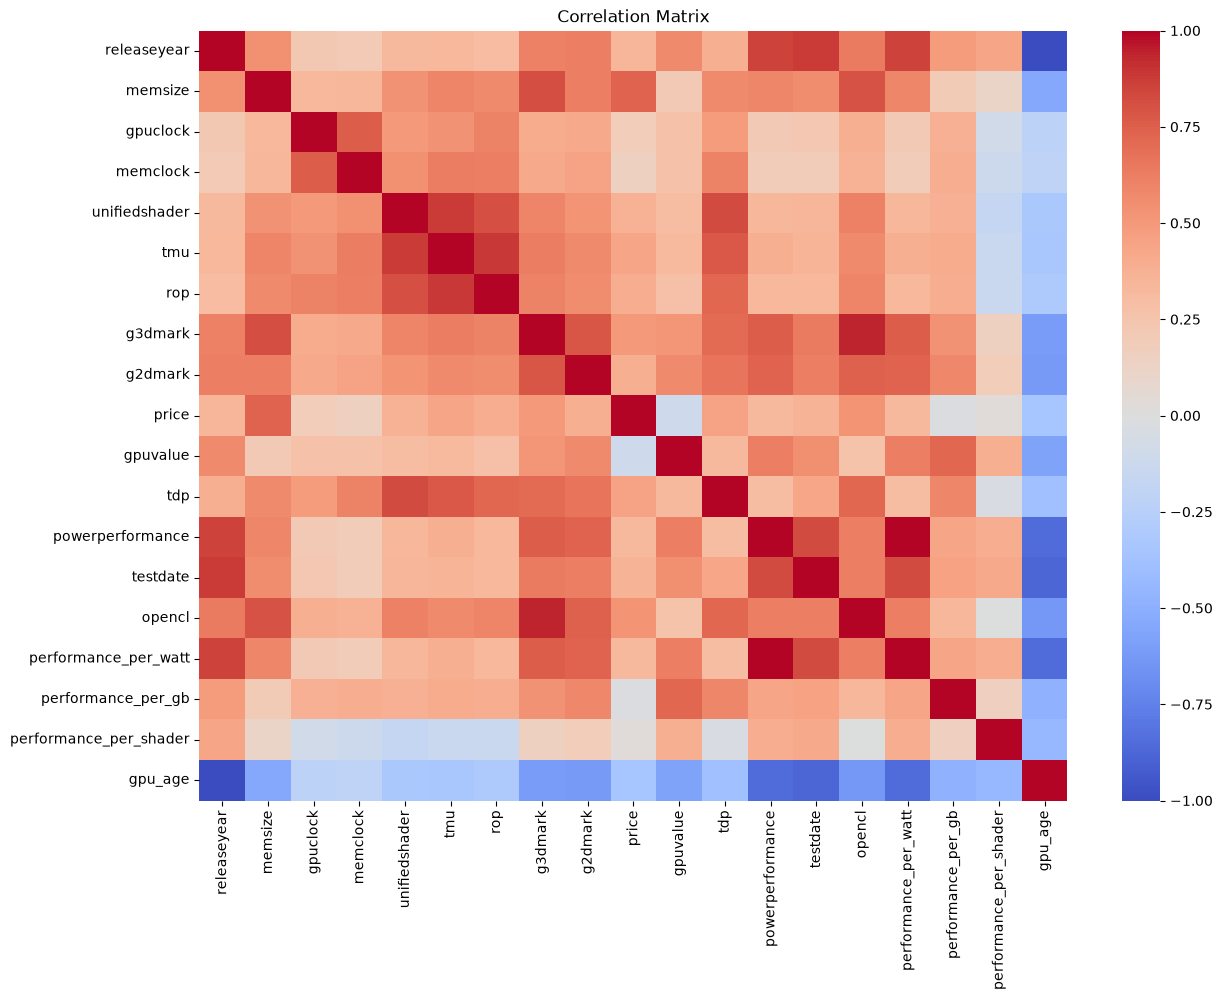

In [15]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14,10))
sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    annot=False
)
plt.title("Correlation Matrix")
plt.show()